# 3D shot gathers (two shots per model)

This notebook use **Deepwave** `scalar` acoustic modeling, Ricker wavelet, receivers on a dense $96~\times~96$ surface grid, and a **free surface** on the top face (`pml_width[0] = 0`).

Here we use **two shots** per velocity model: one at the **middle** of the acquisition surface and one near a **corner** (with a small margin from the edge for stability). A small helper builds geometry and runs the forward model; we then load **four** `vp3d.bin` models and QC each in a **4×3** figure: **`plot3d`** of $v_p$, then center and corner gathers.

In [ ]:
import os, sys
sys.path.insert(0, os.path.expanduser("../quick_start"))

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plotting import plot3d
import string 

import deepwave
from deepwave import scalar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Grid, time axis, and wavelet (match `test_model000` / geofwi3d FWI notebooks)

In [17]:
nz, ny, nx = 96, 96, 96
dz, dy, dx = 10.0, 10.0, 10.0
nt, dt = 501, 0.002
freq = 25.0
peak_time = 1.5 / freq

pml_width = [0, 20, 20, 20, 20, 20]  # free surface on first (top) face


def taper(x):
    return deepwave.common.cosine_taper_end(x, 50)


def load_vp_bin(path, nz: int, ny: int, nx: int, dev: torch.device) -> torch.Tensor:
    """Read float32 binary vp in (nx, ny, nz) file layout; return (nz, ny, nx) tensor on `dev`."""
    path = Path(path)
    v = np.fromfile(path, dtype=np.float32).reshape(nx, ny, nz).T
    return torch.from_numpy(v).to(dev)


def build_two_shot_acquisition(
    ny: int,
    nx: int,
    *,
    source_depth_index: int = 1,
    corner_margin: int = 5,
    dev: torch.device,
):
    """Two shots: (1) map-center on the surface slice, (2) near-origin corner with margin.

    Index order matches geofwi3d: ``[..., 0]`` = z, ``[..., 1]`` = y, ``[..., 2]`` = x.
    """
    n_shots = 2
    mid_y, mid_x = ny // 2, nx // 2
    cy = min(max(corner_margin, 1), ny - 2)
    cx = min(max(corner_margin, 1), nx - 2)

    source_locations = torch.zeros(n_shots, 1, 3, dtype=torch.long, device=dev)
    source_locations[0, 0, 0] = source_depth_index
    source_locations[0, 0, 1] = mid_y
    source_locations[0, 0, 2] = mid_x
    source_locations[1, 0, 0] = source_depth_index
    source_locations[1, 0, 1] = cy
    source_locations[1, 0, 2] = cx

    receiver_locations = torch.zeros(n_shots, ny * nx, 3, dtype=torch.long, device=dev)
    ry, rx = torch.meshgrid(torch.arange(ny).long(), torch.arange(nx).long(), indexing="ij")
    receiver_locations[..., 0] = source_depth_index
    receiver_locations[:, :, 1] = ry.flatten().to(dev)
    receiver_locations[:, :, 2] = rx.flatten().to(dev)

    return source_locations, receiver_locations, n_shots


def generate_shot_gathers(
    v: torch.Tensor,
    *,
    dz: float,
    dy: float,
    dx: float,
    dt: float,
    nt: int,
    freq: float,
    peak_time: float,
    ny: int,
    nx: int,
    dev: torch.device,
    source_depth_index: int = 1,
    corner_margin: int = 5,
    pml_width=None,
    pml_freq=None,
) -> torch.Tensor:
    """Forward 3D acoustic shot gathers for two shots (center + corner); returns tapered data.

    Output shape ``(n_shots, ny * nx, nt)`` (same stacking as geofwi3d notebooks).
    """
    if pml_width is None:
        pml_width = [0, 20, 20, 20, 20, 20]
    if pml_freq is None:
        pml_freq = freq

    source_locations, receiver_locations, n_shots = build_two_shot_acquisition(
        ny, nx, source_depth_index=source_depth_index, corner_margin=corner_margin, dev=dev
    )
    source_amplitudes = deepwave.wavelets.ricker(freq, nt, dt, peak_time).repeat(n_shots, 1, 1).to(dev)

    with torch.no_grad():
        out = scalar(
            v,
            (dz, dy, dx),
            dt,
            source_amplitudes=source_amplitudes,
            source_locations=source_locations,
            receiver_locations=receiver_locations,
            pml_freq=pml_freq,
            pml_width=pml_width,
        )[-1]
    return taper(out)

## Multiple models

By default the first **four** sorted `model_*/vp3d.bin` files under `../allmodels` are used for the 4×3 QC figure. Set `MODEL_PATHS` explicitly if you want a different subset (same 96³ `float32` binary layout).

In [ ]:
base = Path("../allmodels")
MODEL_PATHS = sorted(base.glob("model_*/vp3d.bin"))[:4]
if not MODEL_PATHS:
    MODEL_PATHS = [Path("../output3d/model_0000/vp3d.bin")]

idx = [2217, 6584, 5923, 7056]

MODEL_PATHS = [
    f"../output3d/model_{idx[0]}/vp3d.bin",
    f"../output3d/model_{idx[1]}/vp3d.bin",
    f"../output3d/model_{idx[2]}/vp3d.bin",
    f"../output3d/model_{idx[3]}/vp3d.bin"
]

MODEL_PATHS = [Path(p) for p in MODEL_PATHS]

print("Models:")
for p in MODEL_PATHS:
    print(" ", p.resolve())

per_model = {}
for vp_path in MODEL_PATHS:
    key = vp_path.parent.name
    v_true = load_vp_bin(vp_path, nz, ny, nx, device)
    gathers = generate_shot_gathers(
        v_true,
        dz=dz,
        dy=dy,
        dx=dx,
        dt=dt,
        nt=nt,
        freq=freq,
        peak_time=peak_time,
        ny=ny,
        nx=nx,
        dev=device,
    )
    per_model[key] = {
        "vp": v_true.detach().cpu().numpy().copy(),
        "gathers": gathers.detach().cpu().numpy(),
    }
    del v_true, gathers
    if device.type == "cuda":
        torch.cuda.empty_cache()

list(per_model.keys())


Models:
  /home/mssujith/lanl/NeurIPS26/output3d/model_2217/vp3d.bin
  /home/mssujith/lanl/NeurIPS26/output3d/model_6584/vp3d.bin
  /home/mssujith/lanl/NeurIPS26/output3d/model_5923/vp3d.bin
  /home/mssujith/lanl/NeurIPS26/output3d/model_7056/vp3d.bin


['model_2217', 'model_6584', 'model_5923', 'model_7056']

Each **row** is one velocity model. **Columns:** $v_p$ volume, **center** shot gather, **corner** shot gather. All panels use `plot3d` orthogonal slices.


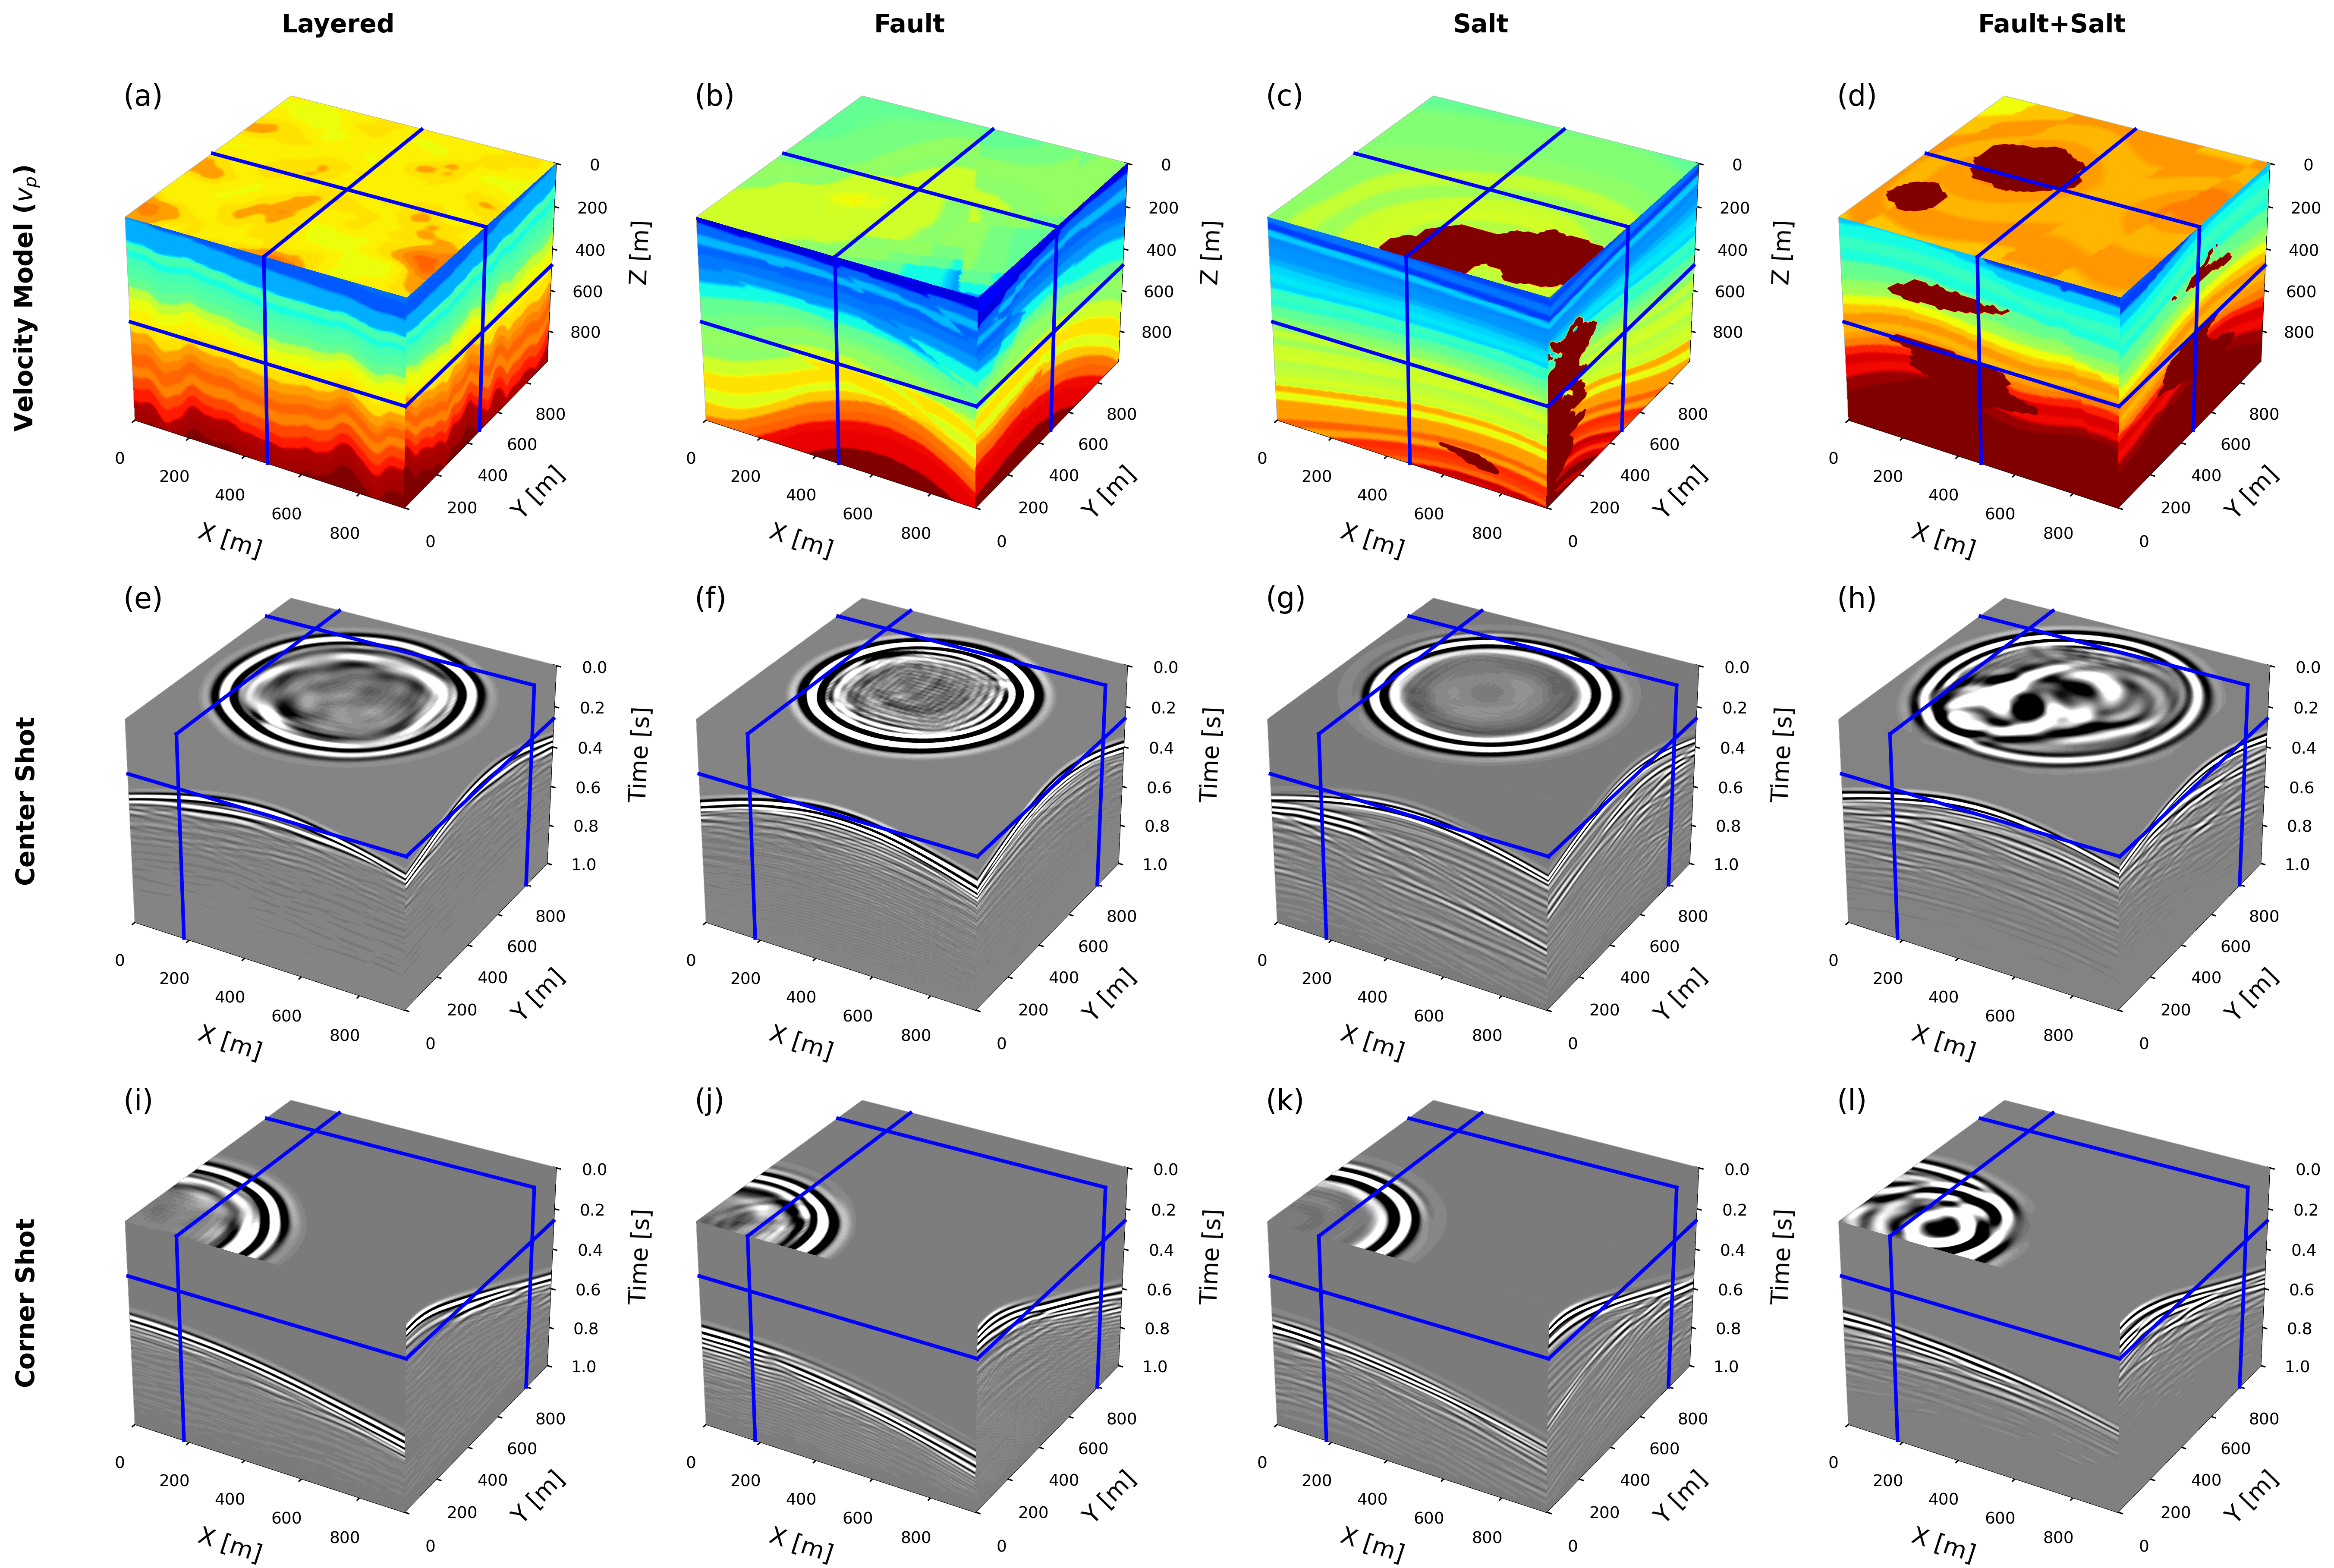

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Global typography and resolution settings for a professional look
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 300
})

n_cols = len(per_model) # Should be 4 based on your request
n_rows = 3

# 2. Set up the figure (width scales with columns, height is fixed for 3 rows)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.5 * n_cols, 12), 
    subplot_kw={"projection": "3d"},
    constrained_layout=True,
)
axes = np.atleast_2d(axes)

vz, vy, vx = nz // 2, ny // 2, nx // 2
shot_frames = [130, 18, 80]

# Row titles for the leftmost column
row_labels = ["Velocity Model ($v_p$)", "Center Shot", "Corner Shot"]

title_list = ["Layered", "Fault", "Salt", "Fault+Salt"]

alphabet = string.ascii_lowercase

for col, (name, bundle) in enumerate(per_model.items()):
    vp = bundle["vp"]
    observed_data_3d = np.asarray(bundle["gathers"]).reshape(2, ny, nx, nt)

    # ---------------------------------------------------------
    # ROW 0: Velocity Models
    # ---------------------------------------------------------
    ax_vp = axes[0, col]
    plt.sca(ax_vp)
    plot3d(
        vp,
        cmap="jet",
        vmin=1500, vmax=3500,
        dx=10.0, dy=10.0, dz=10.0,
        frames=[vz, vy, vx],
        ifinside=False, ifslice=True,
        showf=False, close=False, ifnewfig=False, nlevel=1000,
    )
    # Column Title (Model Name)
    ax_vp.set_title(f"{title_list[col]}", pad=15)
    
    # ---------------------------------------------------------
    # ROW 1: Center Shot (Observed Data 0)
    # ---------------------------------------------------------
    ax_center = axes[1, col]
    plt.sca(ax_center)
    plot3d(
        observed_data_3d[0].T,
        cmap="grey",
        vmin=-0.05, vmax=0.05,
        dx=10.0, dy=10.0, dz=dt,
        frames=shot_frames,
        ifinside=False, ifslice=True,
        showf=False, close=False, ifnewfig=False, nlevel=8000,
    )

    # ---------------------------------------------------------
    # ROW 2: Corner Shot (Observed Data 1)
    # ---------------------------------------------------------
    ax_corner = axes[2, col]
    plt.sca(ax_corner)
    plot3d(
        observed_data_3d[1].T,
        cmap="grey",
        vmin=-0.05, vmax=0.05,
        dx=10.0, dy=10.0, dz=dt,
        frames=shot_frames,
        ifinside=False, ifslice=True,
        showf=False, close=False, ifnewfig=False, nlevel=8000,
    )

    # ---------------------------------------------------------
    # Professional Axis Formatting
    # ---------------------------------------------------------
    for row in range(3):
        ax = axes[row, col]
        ax.tick_params(labelsize=9, pad=5)
        ax.set_xlabel('X [m]', labelpad=10, fontweight='normal')
        ax.set_ylabel('Y [m]', labelpad=10, fontweight='normal')
        
        # Z-axis depends on if it's velocity (depth) or gathers (time)
        if row == 0:
            ax.set_zlabel('Z [m]', labelpad=10, fontweight='normal')
        else:
            ax.set_zlabel('Time [s]', labelpad=10, fontweight='normal')

        # Add Row Labels to the far-left plots
        if col == 0:
            # text2D anchors the text cleanly to the 2D bounding box of the 3D plot
            ax.text2D(
                -0.15, 0.5, 
                row_labels[row], 
                transform=ax.transAxes, 
                fontsize=14, 
                fontweight="bold",
                rotation=90, 
                va='center', 
                ha='center'
            )

        # Calculate row-major index for letters (0 to 11 -> a to l)
        letter_idx = row * n_cols + col
        panel_letter = alphabet[letter_idx]

        # Add the (a), (b), (c)... panel letter inside the top-left of each 3D plot
        ax.text2D(
            0.05, 0.95, 
            f'({panel_letter})', 
            transform=ax.transAxes, 
            fontsize=16, 
            fontweight="normal",
            va='top', 
            ha='left',
            zorder=10
        )


for ax in axes.flatten():
    ax.set_rasterized(True)

# plt.savefig("shot-gathers.pdf", dpi=300, bbox_inches="tight")
plt.show()